In [1]:
import pandas as pd
import os
import sys
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

src_path = '/Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/src'
if src_path not in sys.path:
    sys.path.append(src_path)

from data.load_data import load_data # type: ignore
from models.arima_model import * # type: ignore
from features.transform_features import split_column
from features.clean_features import extract_numeric

In [2]:
data = load_data('/Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/data/raw/Expanded_Cybersecurity_Dataset.csv')

In [3]:
data['Date'] = pd.to_datetime(data['Date'])

In [4]:
data.head()

,Date,Threat_Event_Count,Malware_Detections,Phishing_Attempts,Unauthorized_Access
0,2024-01-01,38,34,35.217214,33
1,2024-01-02,28,37,24.298319,28
2,2024-01-03,14,18,14.318087,13
3,2024-01-04,42,42,49.327400,45
4,2024-01-05,7,4,7.548883,2


In [5]:
data.set_index('Date', inplace=True)

In [6]:
data = data[['Threat_Event_Count']]

In [7]:
check_stationarity(data)

True

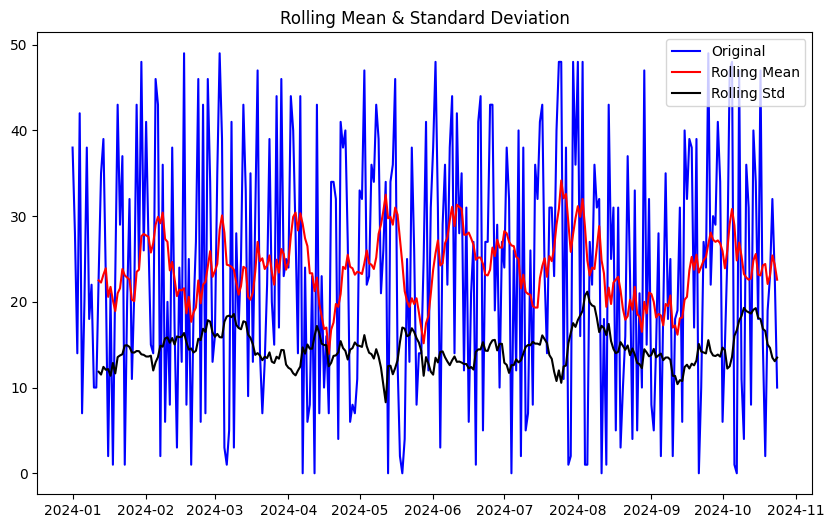

Results of Augmented Dickey-Fuller Test:
Test Statistic: -11.078333819713066
p-value: 4.3749369184575004e-20
# Lags Used: 2
Number of Observations Used: 295
Critical Value (1%): -3.452713099849546
Critical Value (5%): -2.871387839457783
Critical Value (10%): -2.5720171933352485

Interpretation:
The time series is stationary. The null hypothesis of the ADF test (presence of a unit root) is rejected.


In [8]:
from statsmodels.tsa.stattools import adfuller

def visualize_stationarity(data):
	"""
	Visualize stationarity of a time series using rolling statistics and ADF test.
	"""
	rolling_mean = data.rolling(window=12).mean()
	rolling_std = data.rolling(window=12).std()

	# Plot rolling statistics
	plt.figure(figsize=(10, 6))
	plt.plot(data, label='Original', color='blue')
	plt.plot(rolling_mean, label='Rolling Mean', color='red')
	plt.plot(rolling_std, label='Rolling Std', color='black')
	plt.legend(loc='best')
	plt.title('Rolling Mean & Standard Deviation')
	plt.show()

	# Perform Augmented Dickey-Fuller test
	print('Results of Augmented Dickey-Fuller Test:')
	adf_test = adfuller(data.dropna())
	adf_results = {
		'Test Statistic': adf_test[0],
		'p-value': adf_test[1],
		'# Lags Used': adf_test[2],
		'Number of Observations Used': adf_test[3]
	}
	for key, value in adf_test[4].items():
		adf_results[f'Critical Value ({key})'] = value
	for key, value in adf_results.items():
		print(f'{key}: {value}')

	# Interpretation of results
	print("\nInterpretation:")
	if adf_results['p-value'] < 0.05 and adf_results['Test Statistic'] < adf_results['Critical Value (5%)']:
		print("The time series is stationary. The null hypothesis of the ADF test (presence of a unit root) is rejected.")
	else:
		print("The time series is not stationary. The null hypothesis of the ADF test (presence of a unit root) cannot be rejected.")

# Call the function
visualize_stationarity(data)

In [ ]:
# Split the data into training and testing sets
train_size = int(len(data) * 0.8)  # Use 80% of the data for training
train = data.iloc[:train_size]
test = data.iloc[train_size:]

# Display the sizes of the training and testing sets
print(f"Training set size: {len(train)}")
print(f"Testing set size: {len(test)}")

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2024-08-26    22.056195
2024-08-27    23.754422
2024-08-28    19.874105
2024-08-29    24.391829
2024-08-30    22.077306
2024-08-31    22.909652
2024-09-01    22.043635
2024-09-02    22.796979
2024-09-03    22.295227
2024-09-04    22.494336
2024-09-05    22.276810
2024-09-06    22.388018
2024-09-07    22.256040
2024-09-08    22.274051
2024-09-09    22.197880
2024-09-10    22.189987
2024-09-11    22.133305
2024-09-12    22.108249
2024-09-13    22.062685
2024-09-14    22.031428
2024-09-15    21.990177
2024-09-16    21.955561
2024-09-17    21.916561
2024-09-18    21.880567
2024-09-19    21.842502
2024-09-20    21.805827
2024-09-21    21.768224
2024-09-22    21.731252
2024-09-23    21.693849
2024-09-24    21.656737
Freq: D, Name: predicted_mean, dtype: float64


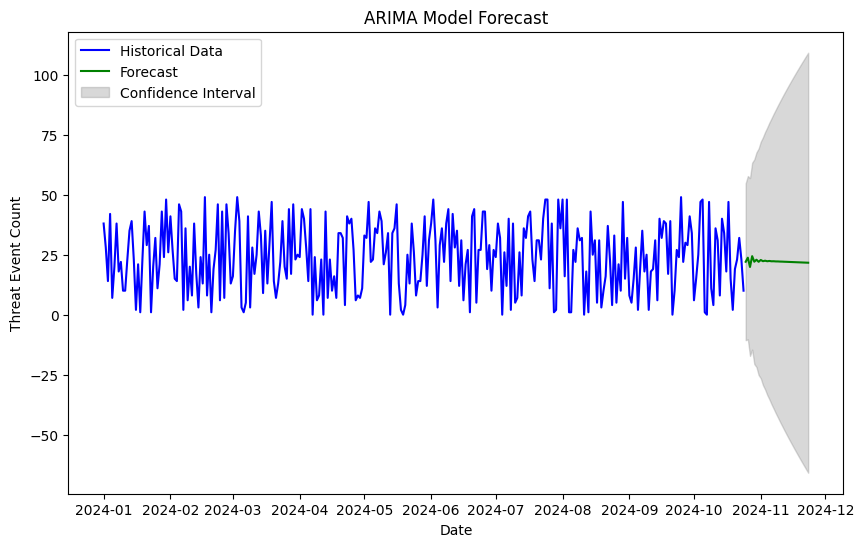

In [71]:

# Ensure "train" is defined
train_size = int(len(data) * 0.8)  # Use 80% of the data for training
train = data.iloc[:train_size]

# Fit the ARIMA model
order = (3, 2, 1)
model = ARIMA(train, order=order)
fitted_model = model.fit()

# Forecast future values
forecast_steps = 30  # Number of steps to forecast
forecast = fitted_model.get_forecast(steps=forecast_steps)

# Extract forecasted values and confidence intervals
forecast_values = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

# Display the forecasted values
print(forecast_values)

# Visualize the forecast
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['Threat_Event_Count'], label='Historical Data', color='blue')
# Ensure data.index is a DatetimeIndex
if not isinstance(data.index, pd.DatetimeIndex):
    data.index = pd.to_datetime(data.index)

# Generate forecasted dates
forecast_dates = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='D')

plt.plot(forecast_dates, forecast_values, label='Forecast', color='green')
plt.fill_between(forecast_dates, 
                 confidence_intervals.iloc[:, 0], confidence_intervals.iloc[:, 1], color='gray', alpha=0.3, label='Confidence Interval')
plt.legend()
plt.title('ARIMA Model Forecast')
plt.xlabel('Date')
plt.ylabel('Threat Event Count')
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

test = data.iloc[train_size:]

# Calculate evaluation metrics
mae = mean_absolute_error(test['Threat_Event_Count'][:forecast_steps], forecast_values)
mse = mean_squared_error(test['Threat_Event_Count'][:forecast_steps], forecast_values)
rmse = np.sqrt(mse)

# Calculate thresholds dynamically
mean_value = test['Threat_Event_Count'].mean()  # Mean of the target variable
std_dev = test['Threat_Event_Count'].std()      # Standard deviation of the target variable
variance = test['Threat_Event_Count'].var()     # Variance of the target variable

# Define thresholds based on data characteristics
baseline_mae = mean_absolute_error(test['Threat_Event_Count'], [mean_value] * len(test))
mae_threshold = 0.9 * baseline_mae  # 10% improvement over the baseline
mse_threshold = variance          # MSE threshold as the variance of the target variable
rmse_threshold = std_dev          # RMSE threshold as the standard deviation

# Display the evaluation metrics
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print("\nThresholds:")
print(f"MAE Threshold: {mae_threshold}")
print(f"MSE Threshold: {mse_threshold}")
print(f"RMSE Threshold: {rmse_threshold}")

# Interpretation of the metrics
print("\nInterpretation:")
print(f"1. Mean Absolute Error (MAE): On average, the forecasted values deviate from the actual values by {mae:.2f} threat events.")
if mae < mae_threshold:
    print("   This is a good result, indicating low average deviation.")
else:
    print("   This is a bad result, indicating high average deviation.")

print(f"2. Mean Squared Error (MSE): The average squared difference between the forecasted and actual values is {mse:.2f}. This metric penalizes larger errors more heavily.")
if mse < mse_threshold:
    print("   This is a good result, indicating low squared errors.")
else:
    print("   This is a bad result, indicating high squared errors.")

print(f"3. Root Mean Squared Error (RMSE): The RMSE of {rmse:.2f} provides a measure of the average magnitude of the forecast errors, expressed in the same units as the data (threat events). Lower values indicate better model performance.")
if rmse < rmse_threshold:
    print("   This is a good result, indicating low forecast error magnitude.")
else:
    print("   This is a bad result, indicating high forecast error magnitude.")

Mean Absolute Error (MAE): 11.114333104104912
Mean Squared Error (MSE): 165.3632065560925
Root Mean Squared Error (RMSE): 12.859362603025568

Thresholds:
MAE Threshold: 10.98
MSE Threshold: 208.09152542372877
RMSE Threshold: 14.425377826030372

Interpretation:
1. Mean Absolute Error (MAE): On average, the forecasted values deviate from the actual values by 11.11 threat events.
   This is a bad result, indicating high average deviation.
2. Mean Squared Error (MSE): The average squared difference between the forecasted and actual values is 165.36. This metric penalizes larger errors more heavily.
   This is a good result, indicating low squared errors.
3. Root Mean Squared Error (RMSE): The RMSE of 12.86 provides a measure of the average magnitude of the forecast errors, expressed in the same units as the data (threat events). Lower values indicate better model performance.
   This is a good result, indicating low forecast error magnitude.


In [67]:
# Check if the new metrics are better than the last stored metrics
last_metrics = metrics_storage.get(order, None)

if last_metrics is None or (mse < last_metrics['MSE'] and 
                            mae < last_metrics['MAE'] and 
                            rmse < last_metrics['RMSE']):
    add_metrics(metrics_storage, order, metrics)
    print("Metrics saved.")
else:
    print("Metrics not saved as they are not better than the last metrics.")

Metrics not saved as they are not better than the last metrics.


In [81]:
metrics_df = pd.DataFrame.from_dict(metrics_storage, orient='index')

# Reset the index and ensure ARIMA_Order is retained as a column
metrics_df.index.name = 'ARIMA_Order'
metrics_df.reset_index(inplace=True)

# Ensure ARIMA_Order exists before splitting into p, d, q
if 'ARIMA_Order' in metrics_df.columns:
    # Split ARIMA_Order into separate columns for p, d, q
    metrics_df[['p', 'd', 'q']] = pd.DataFrame(metrics_df['ARIMA_Order'].tolist(), index=metrics_df.index)
    
    # Drop the original ARIMA_Order column
    metrics_df = metrics_df.drop(columns=['ARIMA_Order'])

    # Reorder columns for better readability
    metrics_df = metrics_df[['p', 'd', 'q', 'MAE', 'MSE', 'RMSE']]

metrics_df.rename(columns={'level_0': 'p', 'level_1': 'd', 'level_2': 'q'}, inplace=True)
print(metrics_df)

   p  d  q        MAE         MSE       RMSE
0  1  1  1  11.464902  178.755368  13.369943
1  3  1  1  11.451703  176.091708  13.269955
2  3  2  1  11.114333  165.363207  12.859363
3  4  4  0  11.114333  165.363207  12.859363
4  4  0  0  11.114333  165.363207  12.859363


/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' wa

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.22 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=2267.228, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=2093.841, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=2188.758, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=2032.198, Time=0.02 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=2027.236, Time=0.04 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=2019.663, Time=0.03 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=2001.069, Time=0.05 sec


/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' wa

 ARIMA(5,0,1)(0,0,0)[0]             : AIC=inf, Time=0.32 sec


/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=1951.283, Time=0.30 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=1950.920, Time=0.20 sec


/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(5,0,1)(0,0,0)[0] intercept   : AIC=1953.047, Time=0.19 sec

Best model:  ARIMA(4,0,0)(0,0,0)[0] intercept
Total fit time: 2.044 seconds
Selected ARIMA order: (4, 0, 0)
2024-08-26    22.056195
2024-08-27    23.754422
2024-08-28    19.874105
2024-08-29    24.391829
2024-08-30    22.077306
2024-08-31    22.909652
2024-09-01    22.043635
2024-09-02    22.796979
2024-09-03    22.295227
2024-09-04    22.494336
2024-09-05    22.276810
2024-09-06    22.388018
2024-09-07    22.256040
2024-09-08    22.274051
2024-09-09    22.197880
2024-09-10    22.189987
2024-09-11    22.133305
2024-09-12    22.108249
2024-09-13    22.062685
2024-09-14    22.031428
2024-09-15    21.990177
2024-09-16    21.955561
2024-09-17    21.916561
2024-09-18    21.880567
2024-09-19    21.842502
2024-09-20    21.805827
2024-09-21    21.768224
2024-09-22    21.731252
2024-09-23    21.693849
2024-09-24    21.656737
Freq: D, Name: predicted_mean, dtype: float64


/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


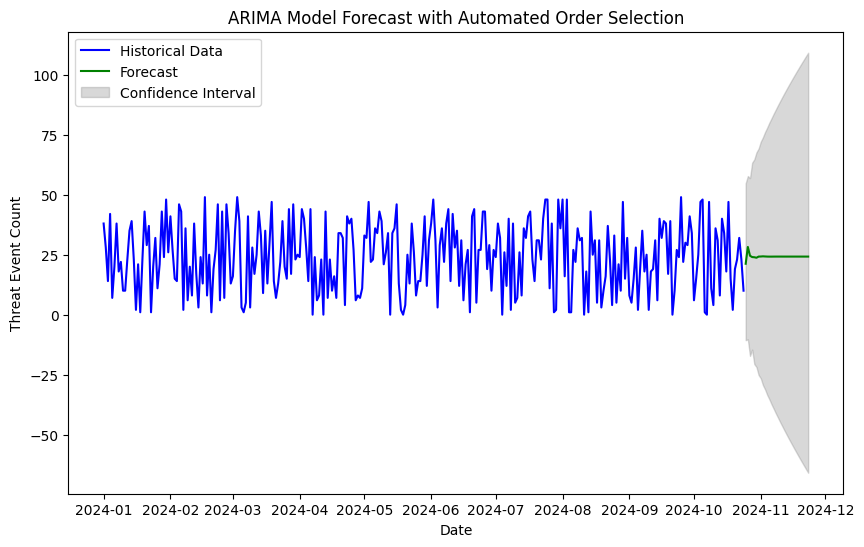

In [77]:
from pmdarima import auto_arima

# Automate the selection of ARIMA order
auto_model = auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True, trace=True)
order = auto_model.order
print(f"Selected ARIMA order: {order}")

# Refit the ARIMA model with the selected order
model = ARIMA(train, order=order)
fitted_model = model.fit()

# Forecast future values
auto_forecast = fitted_model.get_forecast(steps=forecast_steps)
auto_forecast_values = auto_forecast.predicted_mean
auto_confidence_intervals = auto_forecast.conf_int()

# Display the forecasted values
print(forecast_values)

# Visualize the forecast
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['Threat_Event_Count'], label='Historical Data', color='blue')

# Ensure data.index is a DatetimeIndex
if not isinstance(data.index, pd.DatetimeIndex):
    data.index = pd.to_datetime(data.index)

# Generate forecasted dates
forecast_dates = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='D')

plt.plot(forecast_dates, auto_forecast_values, label='Forecast', color='green')
plt.fill_between(forecast_dates, 
                 confidence_intervals.iloc[:, 0], confidence_intervals.iloc[:, 1], color='gray', alpha=0.3, label='Confidence Interval')
plt.legend()
plt.title('ARIMA Model Forecast with Automated Order Selection')
plt.xlabel('Date')
plt.ylabel('Threat Event Count')
plt.show()

In [78]:
test = data.iloc[train_size:]

auto_mae = mean_absolute_error(test['Threat_Event_Count'][:forecast_steps], auto_forecast_values)
auto_mse = mean_squared_error(test['Threat_Event_Count'][:forecast_steps], auto_forecast_values)
auto_rmse = np.sqrt(mse)

# Display the evaluation metrics
print(f"Mean Absolute Error (MAE): {auto_mae}")
print(f"Mean Squared Error (MSE): {auto_mse}")
print(f"Root Mean Squared Error (RMSE): {auto_rmse}")
print("\nThresholds:")
print(f"MAE Threshold: {mae_threshold}")
print(f"MSE Threshold: {mse_threshold}")
print(f"RMSE Threshold: {rmse_threshold}")

Mean Absolute Error (MAE): 11.538524632400927
Mean Squared Error (MSE): 177.90851816682326
Root Mean Squared Error (RMSE): 12.859362603025568

Thresholds:
MAE Threshold: 10.98
MSE Threshold: 208.09152542372877
RMSE Threshold: 14.425377826030372


In [80]:
# Check if the new metrics are better than the last stored metrics
last_metrics = metrics_storage.get(order, None)

if last_metrics is None or (auto_mse < last_metrics['MSE'] and 
                            auto_mae < last_metrics['MAE'] and 
                            auto_rmse < last_metrics['RMSE']):
    add_metrics(metrics_storage, order, metrics)
    print("Metrics saved.")
else:
    print("Metrics not saved as they are not better than the last metrics.")

Metrics not saved as they are not better than the last metrics.
